In [97]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [98]:
data = load_iris(as_frame=True)
display(data.data)
data.target

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [99]:
X = data.data.values
y = data.target
X, y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [100]:
model = DecisionTreeClassifier(max_depth=17, random_state=67)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,17
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,67
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [101]:
data.data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [102]:
export_graphviz(model, out_file="iris_decision_tree.dot", rounded=True, filled=True, feature_names=data.data.columns, class_names=data.target_names)

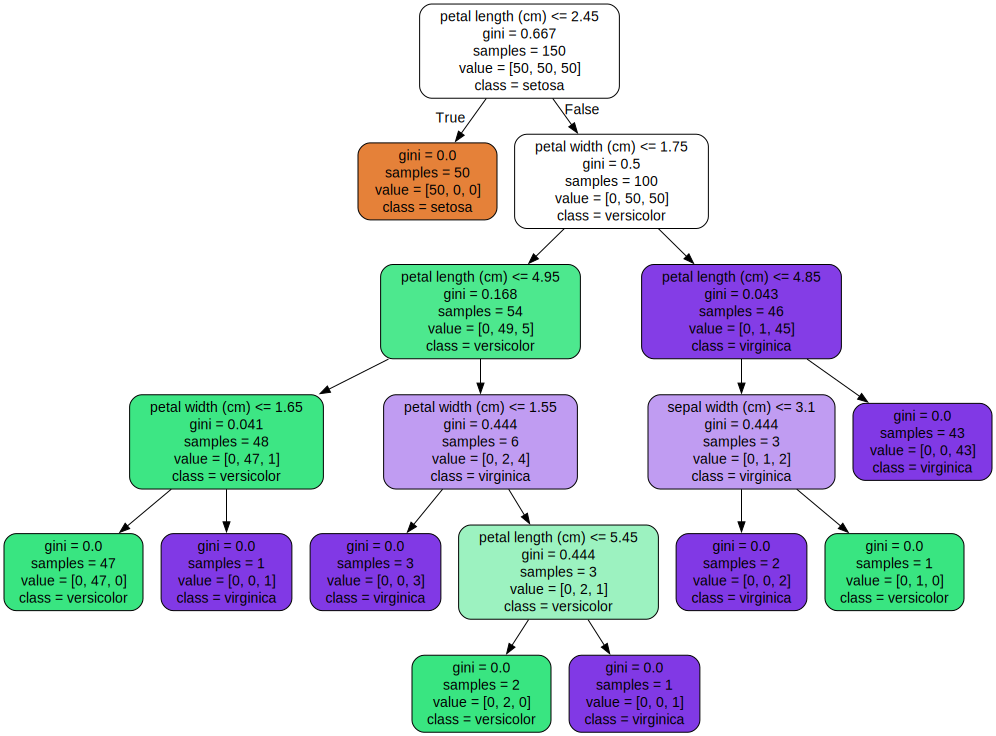

In [103]:
Source.from_file("iris_decision_tree.dot")

In [104]:
print(f"{cross_val_score(model, X, y, scoring="accuracy", cv=50).mean().round(5)*100}%")

95.333%


In [105]:
yPredictions = cross_val_predict(model, X, y, cv=50)

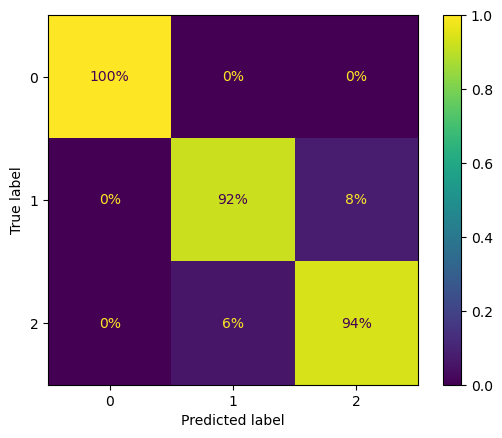

Overall Acuracy: 95.333%


In [106]:

ConfusionMatrixDisplay.from_predictions(y, yPredictions, normalize="true", values_format=".0%")
plt.show()
print(f"Overall Acuracy: {round(accuracy_score(y, yPredictions)*100, 3)}%")


In [107]:
params = {
    "max_depth" :np.arange(1, 18, 1)
}
search = RandomizedSearchCV(model, param_distributions=params, n_iter=17, random_state=67, cv=50, verbose=3, scoring="accuracy", n_jobs=-1, refit=True)
search.fit(X, y)

Fitting 50 folds for each of 17 candidates, totalling 850 fits
[CV 1/50] END ......................max_depth=1;, score=0.667 total time=   0.0s[CV 8/50] END ......................max_depth=1;, score=0.667 total time=   0.0s

[CV 5/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 3/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 9/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 10/50] END .....................max_depth=1;, score=0.667 total time=   0.0s
[CV 2/50] END ......................max_depth=1;, score=0.667 total time=   0.0s[CV 7/50] END ......................max_depth=1;, score=0.667 total time=   0.0s

[CV 4/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 6/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 13/50] END .....................max_depth=1;, score=0.667 total time=   0.0s
[CV 15/50] END .....................max_depth=

,estimator,DecisionTreeC...ndom_state=67)
,param_distributions,"{'max_depth': array([ 1, 2..., 15, 16, 17])}"
,n_iter,17
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,50
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [108]:
resulrDF = pd.DataFrame(search.cv_results_).set_index("rank_test_score").sort_index()
resulrDF

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,split10_test_score,split11_test_score,split12_test_score,split13_test_score,split14_test_score,split15_test_score,split16_test_score,split17_test_score,split18_test_score,split19_test_score,split20_test_score,split21_test_score,split22_test_score,split23_test_score,split24_test_score,split25_test_score,split26_test_score,split27_test_score,split28_test_score,split29_test_score,split30_test_score,split31_test_score,split32_test_score,split33_test_score,split34_test_score,split35_test_score,split36_test_score,split37_test_score,split38_test_score,split39_test_score,split40_test_score,split41_test_score,split42_test_score,split43_test_score,split44_test_score,split45_test_score,split46_test_score,split47_test_score,split48_test_score,split49_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.001235,0.000457,0.000767,0.000073,3,{'max_depth': 3},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.960000,1.083205e-01
2,0.000967,0.000196,0.000643,0.000147,7,{'max_depth': 7},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001023,0.000195,0.000689,0.000162,6,{'max_depth': 6},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001096,0.000146,0.000723,0.000063,5,{'max_depth': 5},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.000904,0.000177,0.000611,0.000112,8,{'max_depth': 8},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001222,0.000302,0.000805,0.000259,11,{'max_depth': 11},1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000

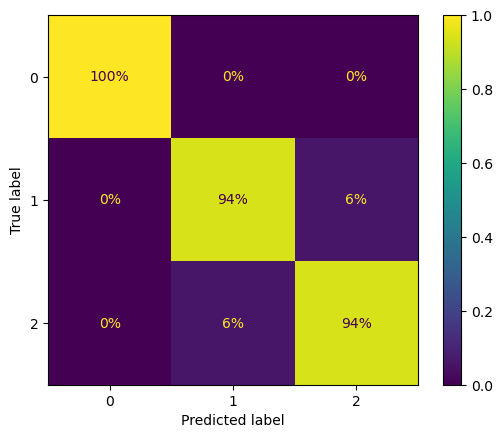

Overall Acuracy: 96.0%


In [109]:
finalModel = search.best_estimator_
yPredictions = cross_val_predict(finalModel, X, y, cv=50)
ConfusionMatrixDisplay.from_predictions(y, yPredictions, normalize="true", values_format=".0%")
plt.show()
print(f"Overall Acuracy: {round(accuracy_score(y, yPredictions)*100, 3)}%")

In [110]:
export_graphviz(finalModel, out_file="iris_decision_tree.dot", rounded=True, filled=True, feature_names=data.data.columns, class_names=data.target_names)

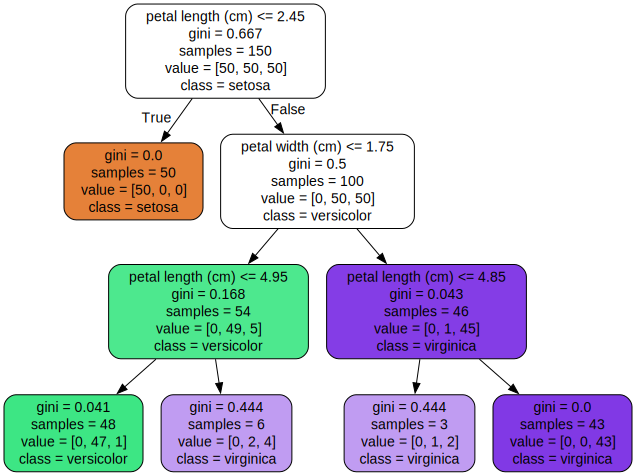

In [111]:
Source.from_file("iris_decision_tree.dot")

In [112]:
XMinumulIris = data.data[["petal length (cm)", "petal width (cm)"]].values
XMinumulIris, y

(array([[1.4, 0.2],
        [1.4, 0.2],
        [1.3, 0.2],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.7, 0.4],
        [1.4, 0.3],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.5, 0.1],
        [1.5, 0.2],
        [1.6, 0.2],
        [1.4, 0.1],
        [1.1, 0.1],
        [1.2, 0.2],
        [1.5, 0.4],
        [1.3, 0.4],
        [1.4, 0.3],
        [1.7, 0.3],
        [1.5, 0.3],
        [1.7, 0.2],
        [1.5, 0.4],
        [1. , 0.2],
        [1.7, 0.5],
        [1.9, 0.2],
        [1.6, 0.2],
        [1.6, 0.4],
        [1.5, 0.2],
        [1.4, 0.2],
        [1.6, 0.2],
        [1.6, 0.2],
        [1.5, 0.4],
        [1.5, 0.1],
        [1.4, 0.2],
        [1.5, 0.2],
        [1.2, 0.2],
        [1.3, 0.2],
        [1.4, 0.1],
        [1.3, 0.2],
        [1.5, 0.2],
        [1.3, 0.3],
        [1.3, 0.3],
        [1.3, 0.2],
        [1.6, 0.6],
        [1.9, 0.4],
        [1.4, 0.3],
        [1.6, 0.2],
        [1.4, 0.2],
        [1.5, 0.2],
        [1.4, 0.2],


In [113]:
preprocessPipeline = Pipeline([
    ("Scale", StandardScaler()),
    ("Optimeze_Axis_Orientation", PCA())
])

processedIris = preprocessPipeline.fit_transform(XMinumulIris)

decissionTreeModel = DecisionTreeClassifier()

pramDist = {
    "max_depth": np.arange(3, 6, 1),
    "min_samples_split": np.arange(2, 11, 1),
    "min_samples_leaf": np.arange(1, 6, 1)
}

randomSearch = RandomizedSearchCV(estimator=decissionTreeModel, random_state=42, param_distributions=pramDist, cv=50, scoring="accuracy", n_jobs=9, n_iter=140, verbose=3, refit=True)

In [114]:
randomSearch.fit(processedIris, y)

/home/mmhe/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 135 is smaller than n_iter=140. Running 135 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 50 folds for each of 135 candidates, totalling 6750 fits
[CV 1/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 2/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 3/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 4/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 5/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 6/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 7/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 10/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 8/50] END max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 11/50] END max_depth=3, min_sa

,estimator,DecisionTreeClassifier()
,param_distributions,"{'max_depth': array([3, 4, 5]), 'min_samples_leaf': array([1, 2, 3, 4, 5]), 'min_samples_split': array([ 2, 3..., 8, 9, 10])}"
,n_iter,140
,scoring,'accuracy'
,n_jobs,9
,refit,True
,cv,50
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [115]:
df = pd.DataFrame(randomSearch.cv_results_).set_index("rank_test_score").sort_index()
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_samples_split,param_min_samples_leaf,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,split10_test_score,split11_test_score,split12_test_score,split13_test_score,split14_test_score,split15_test_score,split16_test_score,split17_test_score,split18_test_score,split19_test_score,split20_test_score,split21_test_score,split22_test_score,split23_test_score,split24_test_score,split25_test_score,split26_test_score,split27_test_score,split28_test_score,split29_test_score,split30_test_score,split31_test_score,split32_test_score,split33_test_score,split34_test_score,split35_test_score,split36_test_score,split37_test_score,split38_test_score,split39_test_score,split40_test_score,split41_test_score,split42_test_score,split43_test_score,split44_test_score,split45_test_score,split46_test_score,split47_test_score,split48_test_score,split49_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.000781,0.000159,0.000599,0.000116,2,1,3,"{'min_samples_split': 2, 'min_samples_leaf': 1...",1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.980000,0.079162
1,0.000699,0.000145,0.000581,0.000125,3,1,3,"{'min_samples_split': 3, 'min_samples_leaf': 1...",1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.980000,0.079162
1,0.000699,0.000156,0.000607,0.000131,4,1,3,"{'min_samples_split': 4, 'min_samples_leaf': 1...",1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.980000,0.079162
1,0.000679,0.000133,0.000556,0.000095,5,1,3,"{'min_samples_split': 5, 'min_samples_leaf': 1...",1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.980000,0.079162
1,0.000807,0.000093,0.000683,0.000090,6,1,3,"{'min_samples_split': 6, 'min_samples_leaf': 1...",1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,1.000000,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.980000,0.079162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,0.000865,0.000024,0.000764,0.000016,5,3,5,"{'min_samples_split': 5, 'min_samples_leaf': 3...",1.0,1.0,1.0,1.0,1.0,1.0,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.946667,0.122202
130,0.000684,0.000128,0.000592,0.000112,7,3,4,"{'min_samples_split': 7, 'min_samples_leaf': 3...",1.0,1.0,1.0,1.0,1.0,1.0,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,1.0,1.0,0.666667,0.666667,1.0,1.0,1.0,0.666667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.946667,0.122202
130,0.000868,0.000039,0.000752,0.000024,8,4,4,"{'min_samples_split': 8, 'min_samples_leaf': 4...",

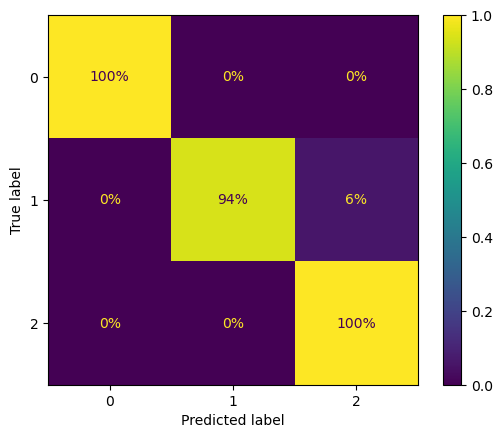

Overall Acuracy: 98.0%


In [116]:
finalFinalModel = randomSearch.best_estimator_
yPredictionsTwo = cross_val_predict(finalFinalModel, processedIris, y, cv=50)
ConfusionMatrixDisplay.from_predictions(y, yPredictionsTwo, normalize="true", values_format=".0%")
plt.show()
print(f"Overall Acuracy: {round(accuracy_score(y, yPredictionsTwo)*100, 3)}%")

In [117]:
export_graphviz(randomSearch.best_estimator_, rounded=True, filled=True, out_file="main_iris_decission_tree.dot", feature_names=["petal length (cm)", "petal width (cm)"], class_names=data.target_names)

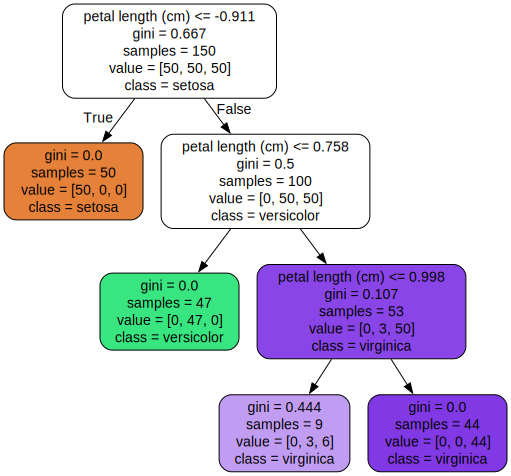

In [118]:
Source.from_file("main_iris_decission_tree.dot")